# MWE: imaging real PIONIER data of a circumbinary disc

IRAS 08544-4431 is a post-AGB binary surrounded by a disc of hot dust. Hillen et al. (2016, arXiv:1603.03023) imaged it with PIONIER at the VLTI: H band, six spectral channels from 1.53 to 1.77 µm, and three configurations of the Auxiliary Telescopes in January and February 2015. They used SPARCO, which splits the scene into a star with a stellar spectrum, a fully resolved background and an image of the rest, with its own spectral index.

This notebook does the same with drpangloss, using the 27 calibrated OIFITS files of that programme, and compares the results with the paper's text. It first fits a parametric model: a star, an inclined Gaussian ring and a resolved background. It then reconstructs a maximum-entropy image with the star and background held analytic. You should come away knowing how to take real long-baseline data from OIFITS to a SPARCO image with `read_oifits`, `fit` and `l_curve`. The data are not in this repository: set `DATA` to wherever they live.

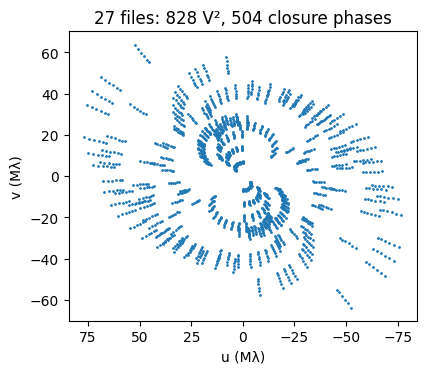

In [1]:
import sys
from pathlib import Path

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists())
sys.path.insert(0, str(root / "src"))

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as onp
import numpyro.distributions as dist

from drpangloss.fitting import fit
from drpangloss.imaging import MaxEntropy, beam, diagnose, field_of_view, image_priors, l_curve
from drpangloss.models import Image, ModulatedGaussianRim, PointSource, Resolved, System, circular_support
from drpangloss.oidata import OIData
from drpangloss.oifits import read_oifits
from drpangloss.plotting import plot_model, plot_residual_map
from drpangloss.spectra import PowerLaw

DATA = Path("/Users/benpope/code/nuHor/data/ep1")
files = sorted(DATA.glob("PIONI.*_oidataCalibrated.fits"))
data = OIData(read_oifits(files))

fig, ax = plt.subplots(figsize=(4.5, 4.5))
u, v = data.u / data.wavel / 1e6, data.v / data.wavel / 1e6
ax.plot(jnp.concatenate([u, -u]), jnp.concatenate([v, -v]), ".", ms=2)
ax.set(xlabel="u (Mλ)", ylabel="v (Mλ)", aspect="equal", title=f"{len(files)} files: {data.vis.size} V², {data.phi.size} closure phases")
ax.invert_xaxis()
plt.show()

## A parametric SPARCO model

The star is a point source whose flux follows a Rayleigh–Jeans power law, F_λ ∝ λ⁻⁴. The disc is an inclined Gaussian ring with a first-order azimuthal modulation (`ModulatedGaussianRim`), and the background is a fully resolved component (`Resolved`). Both have power-law spectra with free ratios at 1.65 µm and free indices. The flux fractions printed are at 1.65 µm.

In [2]:
L0 = 1.65e-6
model = System(
    star=PointSource(flux=PowerLaw(1.0, -4.0, L0)),
    rim=ModulatedGaussianRim(14.0, 3.0, 20.0, 0.0, az_amps=(0.1,), az_pas=(0.0,), flux=PowerLaw(0.35, 0.0, L0)),
    bg=Resolved(flux=PowerLaw(0.25, 0.0, L0)),
)
priors = {
    "rim.diam": dist.Uniform(2.0, 40.0), "rim.fwhm": dist.Uniform(0.1, 20.0), "rim.inc": dist.Uniform(0.0, 89.0),
    "rim.pa": dist.Uniform(-90.0, 270.0), "rim.az_amps": dist.Uniform(0.0, 1.0), "rim.az_pas": dist.Uniform(-180.0, 540.0),
    "rim.flux.ratio": dist.Uniform(0.0, 5.0), "rim.flux.index": dist.Uniform(-10.0, 10.0),
    "bg.flux.ratio": dist.Uniform(0.0, 5.0), "bg.flux.index": dist.Uniform(-10.0, 10.0),
}
parametric = fit(model, priors, data, method="lbfgs")
p = parametric.values
total = 1.0 + p["rim.flux.ratio"] + p["bg.flux.ratio"]
print(f"chi2 per point {parametric.info['chi2_red']:.2f}")
print(f"ring: diameter {float(p['rim.diam']):.2f} mas, FWHM {float(p['rim.fwhm']):.2f} mas, inclination {float(p['rim.inc']):.1f}°, major-axis PA {float(p['rim.pa']):.0f}°")
print(f"flux at 1.65 µm: star {1 / total:.1%}, ring {p['rim.flux.ratio'] / total:.1%}, background {p['bg.flux.ratio'] / total:.1%}")

W1001 15:09:42.423193 10668409 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


chi2 per point 5.25
ring: diameter 14.37 mas, FWHM 3.29 mas, inclination 21.8°, major-axis PA -22°
flux at 1.65 µm: star 62.1%, ring 21.4%, background 16.5%


## Reconstructing the image

The image starts from the fitted ring. It is 80 pixels of 0.6 mas, so it covers the 48 mas interferometric field of view, with a hole of half a beam under the star. The star keeps its λ⁻⁴ spectrum, and the image gets a `PowerLaw` flux with a free ratio and index. The resolved background is held at its parametric value. A smooth image spread over the whole field has almost no visibility on any of these baselines, so it is indistinguishable from a resolved background; left free, the background flux drains into the image's outskirts. The maximum-entropy weight is swept with `l_curve` and chosen by the discrepancy principle.

In [3]:
npix, scale = 80, 0.6
fov = npix * scale
hole = circular_support(npix, scale, fov, 0.5 * beam(data).minor_mas)
start = System(
    star=PointSource(flux=PowerLaw(1.0, -4.0, L0)),
    env=Image.from_model(parametric.model.rim.set("flux", 1.0), npix, scale, support=hole, flux=PowerLaw(p["rim.flux.ratio"], p["rim.flux.index"], L0)),
    bg=parametric.model.bg,
)
image_prior = image_priors(start) | {"env.flux.ratio": dist.Uniform(0.0, 5.0), "env.flux.index": dist.Uniform(-10.0, 10.0)}
curve = l_curve(start, image_prior, data, MaxEntropy(1.0, path="env"), jnp.logspace(1, 4, 7))
chosen = int(jnp.argmin(jnp.abs(jnp.log(curve.weights) - jnp.log(curve.discrepancy() or curve.corner()))))
result = curve.results[chosen]
q = result.values
total = 1.0 + q["env.flux.ratio"] + p["bg.flux.ratio"]
print(f"field {fov:.0f} mas (interferometric {field_of_view(data):.0f} mas); weight {float(curve.weights[chosen]):.3g}; chi2 per point {float(curve.chi2_red[chosen][0]):.2f}")
print(f"image flux at 1.65 µm {q['env.flux.ratio'] / total:.1%}, spectral index {float(q['env.flux.index']):.2f}")

/Users/benpope/code/drpangloss/src/drpangloss/imaging.py:665: RuntimeWarning: fit(method='lbfgs') did not converge in 20000 steps.
  result = fit(


field 48 mas (interferometric 48 mas); weight 316; chi2 per point 0.94
image flux at 1.65 µm 22.9%, spectral index 1.55


## The image

On the left is the central 30 mas of the reconstruction, with the beam shaded. The colour scale saturates the brightest 0.5% of pixels: a few compact pixels just outside the hole under the star are much brighter than the ring. The data need them. With a hole of a whole beam, χ² per point at this weight rises from 1.06 to 1.28. On the right is its signed difference from the parametric ring, with both normalised to unit flux: this is what the image adds beyond a smooth modulated ring. There is no truth to compare with, and a MAP image has no uncertainties, so these are not z-scores.

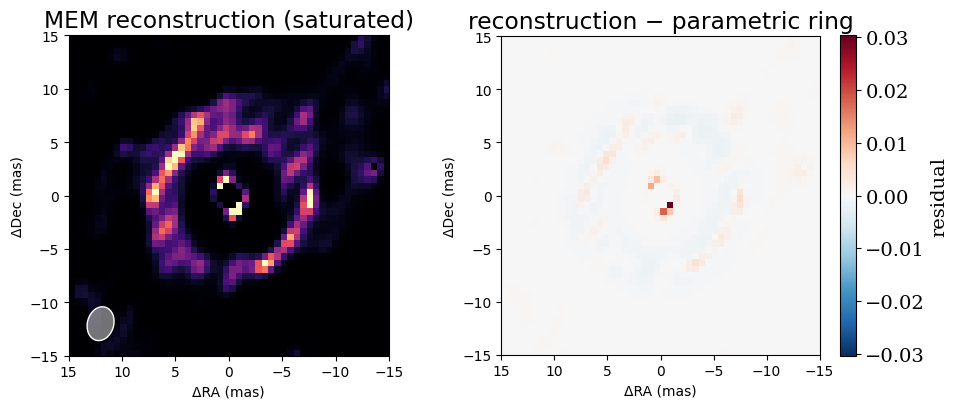

In [4]:
view, nview = 30.0, 50  # the central 30 mas, at the image's pixel scale
image = result.model.env.render(nview, view)
ring = parametric.model.rim.render(nview, view)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
plot_model(result.model.env, fov_mas=view, npix=nview, ax=axes[0], title="MEM reconstruction (saturated)", saturate=0.995, beam=beam(data))
plot_residual_map(image - ring, fov_mas=view, ax=axes[1], title="reconstruction − parametric ring")
plt.tight_layout()
plt.show()

## The ring's radial profile

To measure the ring in the image, the image is deprojected using the parametric fit's inclination and position angle, then averaged in annuli. The dashed line marks the parametric ring's radius. The spike at 1.5 mas is the compact central emission just outside the hole; the ring's peak is reported beyond 2 mas.

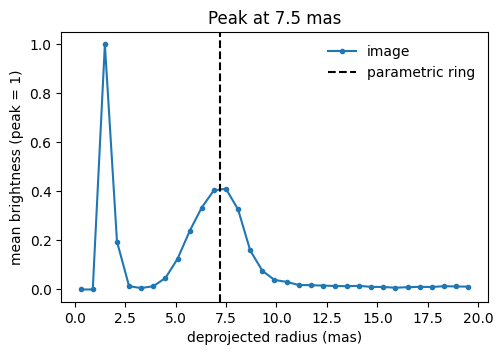

In [5]:
centres = (onp.arange(npix)[::-1] - (npix - 1) / 2) * scale
xx, yy = onp.meshgrid(centres, centres)  # East (left) and North (up), in mas
pa, inc = onp.radians(float(p["rim.pa"])), onp.radians(float(p["rim.inc"]))
along, across = xx * onp.sin(pa) + yy * onp.cos(pa), xx * onp.cos(pa) - yy * onp.sin(pa)
radius = onp.hypot(along, across / onp.cos(inc))
edges = onp.arange(0.0, 20.0, scale)
profile = onp.histogram(radius, edges, weights=onp.asarray(result.model.env.render(npix, fov)))[0] / onp.maximum(onp.histogram(radius, edges)[0], 1)
mid = 0.5 * (edges[1:] + edges[:-1])

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(mid, profile / profile.max(), "o-", ms=3, label="image")
ax.axvline(float(p["rim.diam"]) / 2, color="k", ls="--", label="parametric ring")
ax.set(xlabel="deprojected radius (mas)", ylabel="mean brightness (peak = 1)", title=f"Peak at {mid[onp.argmax(profile * (mid > 2))]:.1f} mas")
ax.legend(frameon=False)
plt.show()

## Diagnostics

`diagnose` on the reconstruction. The star anchors the image, and turning the image by 180° makes χ² far worse, so the closure phases constrain its orientation.

In [6]:
print(diagnose(result.model, data))

chi2_red         [0.944]
anchored         True
pixel_scale_mas  [0.6]
edge_flux        [0.0132]
centroid_mas     [[-0.0528, 1.03]]
flip_dchi2       5.07e+04

No warnings.


## Comparison with the paper, and summary

Hillen et al. report the following, from their text:
- a ring of diameter 14.15 ± 0.10 mas, about 2 au, with a Gaussian width of 3.2 mas FWHM;
- an inclination of 19 ± 2°;
- flux fractions at 1.65 µm of 59.7% (primary), 3.9% (secondary), 20.9% (ring) and 15.5% (resolved background);
- an environment spectral index of 0.42 in the convention where the star's is −4, as here;
- azimuthal modulations of the ring;
- a binary of separation 0.81 mas.

The parametric fit gives a ring 14.4 mas across and 3.3 mas wide, an inclination of 22°, and fractions of 62% (star, which includes their secondary), 21% (ring) and 17% (background). Those are within a few per cent of theirs, from an independent fit to the same data. The image shows the ring at the same radius, brighter on one side, and the profile peaks near the parametric radius.

The spectral index differs: the image's is about 1.5, against their 0.42. The likeliest cause is the background, which here is held at its parametric spectrum, rather than fitted with the image as in their SPARCO setup; its flux and spectrum trade off against the image's.

The binary is not fitted here. The compact emission just outside the hole is where its signature lands. A parametric secondary has a local minimum at 0.80 mas and about 4% of the flux, close to their values, but the data prefer an unresolved, nearly equal pair at 0.44 mas, which is a slightly resolved central source rather than a detection. It needs the secondary's spectrum and the circum-companion emission they describe to be modelled together.

The workflow is general: `read_oifits` on a list of files, a parametric SPARCO model to fix the star and background, and `l_curve` for a regularised image, ending with `diagnose`.